In [7]:
import os
import pandas as pd
import chardet

def detectar_codificacion(archivo):
    """Detecta la codificación del archivo para evitar errores al leerlo."""
    with open(archivo, 'rb') as f:
        resultado = chardet.detect(f.read(10000))  # Leer las primeras 10,000 bytes
    return resultado['encoding']

def cargar_csvs_en_dataframe(carpeta):
    """Carga todos los archivos CSV en DataFrames y los almacena en un diccionario, manejando diferentes codificaciones."""
    archivos = [f for f in os.listdir(carpeta) if f.endswith('.csv')]
    dataframes = {}
    
    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        encoding_detectado = detectar_codificacion(ruta)
        
        df = pd.read_csv(ruta, sep=',', encoding=encoding_detectado, on_bad_lines='skip', engine='python')  # Maneja caracteres no reconocidos
        df['source_file'] = archivo  # Agrega el nombre del archivo como columna
        dataframes[archivo] = df
    
    return dataframes

def mostrar_columnas(dataframes):
    """Muestra las columnas de cada archivo CSV cargado."""
    for nombre, df in dataframes.items():
        print(f"\nArchivo: {nombre}")
        print(df.columns)

# Carpeta donde están los CSV
carpeta_datos = r'C:\Users\alber\OneDrive\Escritorio\data_set'  # Ajusta esta ruta según donde tengas los archivos

# Cargar los datos
dataframes = cargar_csvs_en_dataframe(carpeta_datos)

# Mostrar columnas de cada dataset para encontrar claves comunes
mostrar_columnas(dataframes)


Archivo: Activos por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo %.csv
Index(['Edad;Sexo;Unidad;Periodo;Total', 'source_file'], dtype='object')

Archivo: Activos por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo.csv
Index(['Edad;Sexo;Unidad;Periodo;Total', 'source_file'], dtype='object')

Archivo: Distribución porcentual de los parados por sector económico, sexo y grupo de edad %.csv
Index(['Sexo;Edad;Sector económico;Periodo;Total', 'source_file'], dtype='object')

Archivo: Ocupados por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo &.csv
Index(['Edad;Sexo;Unidad;Periodo;Total', 'source_file'], dtype='object')

Archivo: Ocupados por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexoç.csv
Index(['Edad;Sexo;Unidad;Periodo;Total', 'source_file'], dtype='object')

Archivo: Parados por sexo y grupo de edad. Valores absolutos y porcenta

In [5]:
# Especifica el nombre del archivo cuyo dataframe quieres ver
nombre_archivo = 'Activos por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo.csv'  # Reemplázalo con el nombre real

# Verificar si el archivo está en el diccionario y mostrar sus columnas
if nombre_archivo in dataframes:
    print(f"Columnas del archivo {nombre_archivo}:")
    print(dataframes[nombre_archivo].head)
else:
    print(f"El archivo {nombre_archivo} no se encuentra en los datos cargados.")


Columnas del archivo Activos por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo.csv:
<bound method NDFrame.head of                                                     Edad;Sexo;Unidad;Periodo;Total  \
De 16 a 19 años;Ambos sexos;Valor absoluto;2024...                             9.0   
De 16 a 19 años;Ambos sexos;Valor absoluto;2024...                             9.0   
De 16 a 19 años;Ambos sexos;Valor absoluto;2024...                             3.0   
De 16 a 19 años;Ambos sexos;Valor absoluto;2024...                             2.0   
De 16 a 19 años;Ambos sexos;Valor absoluto;2023...                             5.0   
...                                                                            ...   
70 y más años;Mujeres;Valor absoluto;2016T1;13                                 NaN   
70 y más años;Mujeres;Valor absoluto;2015T4;13                                 6.0   
70 y más años;Mujeres;Valor absoluto;2015T3;11                          

In [6]:
import pandas as pd

# Cargar y unificar los datasets similares
def cargar_y_limpiar_csv(ruta, separador=';', encoding='latin1'):
    try:
        df = pd.read_csv(ruta, sep=separador, encoding=encoding)
        df.columns = [col.strip() for col in df.columns]  # Eliminar espacios en nombres de columnas
        df['source_file'] = ruta  # Agregar el nombre del archivo como referencia
        return df
    except Exception as e:
        print(f"Error al leer el archivo {ruta}: {e}")
        return pd.DataFrame()  # Retorna un DataFrame vacío para evitar fallos en `concat`

# Consolidar activos, ocupados y parados
archivos_laborales = [
    r"C:\Users\alber\OneDrive\Escritorio\data_set\Activos por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo %.csv",
    r"C:\Users\alber\OneDrive\Escritorio\data_set\Ocupados por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo &.csv",
    r"C:\Users\alber\OneDrive\Escritorio\data_set\Parados por sexo y grupo de edad. Valores absolutos y porcentajes respecto del total de cada sexo %.csv"
]

df_laboral = pd.concat([cargar_y_limpiar_csv(f) for f in archivos_laborales], ignore_index=True)
df_laboral = df_laboral[['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file']]
df_laboral.to_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv", index=False, encoding='utf-8')

# Consolidar tasas de actividad y de paro
archivos_tasas = [
    r"C:\Users\alber\OneDrive\Escritorio\data_set\Tasas de actividad por sexo y grupo de edad.csv",
    r"C:\Users\alber\OneDrive\Escritorio\data_set\Tasas de paro por distintos grupos de edad, sexo y comunidad autónoma.csv"
]

df_tasas = pd.concat([cargar_y_limpiar_csv(f) for f in archivos_tasas], ignore_index=True)
df_tasas = df_tasas[['Edad', 'Sexo', 'Periodo', 'Total', 'source_file']]
df_tasas.to_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv", index=False, encoding='utf-8')

# Cargar sectores económicos
archivo_sectores = r"C:\Users\alber\OneDrive\Escritorio\data_set\Distribución porcentual de los parados por sector económico, sexo y grupo de edad %.csv"
df_sectores = cargar_y_limpiar_csv(archivo_sectores)
df_sectores = df_sectores[['Sexo', 'Edad', 'Sector económico', 'Periodo', 'Total']]
df_sectores.to_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv", index=False, encoding='utf-8')

# Cargar datos de formación
archivo_formacion = r"C:\Users\alber\OneDrive\Escritorio\data_set\Tasas de paro por nivel de formación alcanzado, sexo y grupo de edad.csv"
df_formacion = cargar_y_limpiar_csv(archivo_formacion)
df_formacion = df_formacion[['Sexo', 'Edad', 'Nivel de formación alcanzado', 'Periodo', 'Total']]
df_formacion.to_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv", index=False, encoding='utf-8')

# Cargar datos de productividad
archivo_productividad = r"C:\Users\alber\OneDrive\Escritorio\data_set\Productividad y costes laborales.csv"
df_productividad = cargar_y_limpiar_csv(archivo_productividad)
df_productividad = df_productividad[['Ratios relevantes', 'Tipo de dato', 'Niveles y Tasas', 'Periodo', 'Total']]
df_productividad.to_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv", index=False, encoding='utf-8')

print(r"Consolidación completada. Archivos guardados en 'C:\Users\alber\OneDrive\Escritorio\data_set_consolidado'")


Consolidación completada. Archivos guardados en 'C:\Users\alber\OneDrive\Escritorio\data_set_consolidado'


In [18]:
import pandas as pd

# Cargar los datasets consolidados
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Mostrar primeras filas de cada dataset
print(df_laboral.head())
print(df_tasas.head())


              Edad         Sexo      Unidad Periodo Total  \
0  De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   1,2   
1  De 16 a 19 años  Ambos sexos  Porcentaje  2024T3   1,6   
2  De 16 a 19 años  Ambos sexos  Porcentaje  2024T2   1,4   
3  De 16 a 19 años  Ambos sexos  Porcentaje  2024T1   1,2   
4  De 16 a 19 años  Ambos sexos  Porcentaje  2023T4   1,1   

                                         source_file  
0  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
1  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
2  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
3  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
4  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
              Edad         Sexo Periodo  Total  \
0  De 16 a 19 años  Ambos sexos  2024T4  13,95   
1  De 16 a 19 años  Ambos sexos  2024T3  18,19   
2  De 16 a 19 años  Ambos sexos  2024T2  15,68   
3  De 16 a 19 años  Ambos sexos  2024T1  13,65   
4  De 16 a 19 años  Ambos sexos  2023T4  13,28   

  

In [19]:
import pandas as pd

# Cargar los archivos CSV en DataFrames
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Lista con los DataFrames
ruta_datos = [df_laboral, df_tasas, df_sectores, df_formacion, df_productividad]

# Si necesitas concatenarlos en un solo DataFrame
df_consolidado = pd.concat(ruta_datos, axis=0, ignore_index=True)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Inspeccionar los datos
print(df.info())
print(df.describe())

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(x='Periodo', y='Total', data=df, hue='Sexo')
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.show()

# Selección de características y target
features = ['Edad', 'Sexo', 'Unidad']  # Ajustar según los datos disponibles
df = pd.get_dummies(df, columns=['Sexo', 'Unidad'], drop_first=True)  # One-Hot Encoding
df = df.dropna()  # Eliminar valores nulos
X = df[features]
y = df['Total']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar modelos
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# Evaluación de modelos
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
    print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

evaluar_modelo(model_rf, X_test, y_test)
evaluar_modelo(model_xgb, X_test, y_test)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\alber\\OneDrive\\Escritorio\\data_set_consolidado'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                                4320  
unique                                                  3  
top     

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\1464543309.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


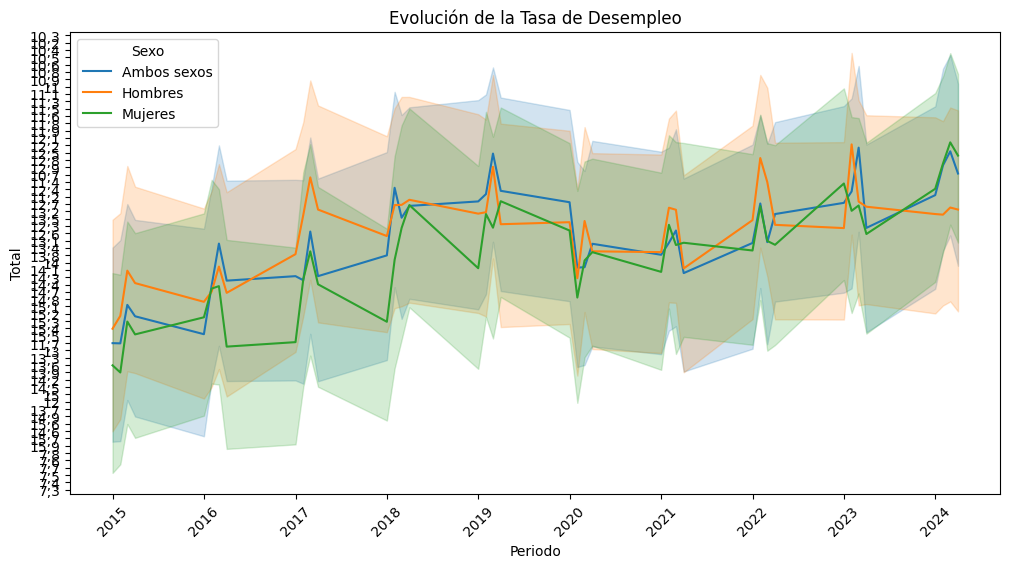

KeyError: "['Sexo', 'Unidad'] not in index"

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ejemplo usando df_laboral, ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(x='Periodo', y='Total', data=df, hue='Sexo')  # Asegúrate de que la columna 'Sexo' exista
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.show()

# Selección de características y target
features = ['Edad', 'Sexo', 'Unidad']  # Ajustar según los datos disponibles en tu dataset
df = pd.get_dummies(df, columns=['Sexo', 'Unidad'], drop_first=True)  # One-Hot Encoding
df = df.dropna()  # Eliminar filas con valores nulos

# Verificar si la columna 'Total' está presente
if 'Total' not in df.columns:
    print("La columna 'Total' no está presente en el dataset.")
else:
    X = df[features]
    y = df['Total']

    # Dividir en conjunto de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar las características
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Entrenar modelos
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

    model_rf.fit(X_train, y_train)
    model_xgb.fit(X_train, y_train)

    # Evaluación de modelos
    def evaluar_modelo(modelo, X_test, y_test):
        y_pred = modelo.predict(X_test)
        print(f"Modelo: {modelo.__class__.__name__}")
        print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
        print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

    evaluar_modelo(model_rf, X_test, y_test)
    evaluar_modelo(model_xgb, X_test, y_test)


In [21]:
print(df.columns)


Index(['Edad', 'Periodo', 'Total', 'source_file', 'Sexo_Hombres',
       'Sexo_Mujeres'],
      dtype='object')


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ejemplo usando df_laboral, ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))
sns.lineplot(x='Periodo', y='Total', data=df, hue='Sexo_Hombres')  # Asegúrate de que 'Sexo_Hombres' sea la columna correcta
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.show()

# Selección de características y target
if 'Sexo_Hombres' in df.columns and 'Sexo_Mujeres' in df.columns:
    features = ['Edad', 'Sexo_Hombres', 'Sexo_Mujeres']  # Ajustar según los datos disponibles
    df = df.dropna()  # Eliminar filas con valores nulos

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        X = df[features]
        y = df['Total']

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("Las columnas 'Sexo_Hombres' y 'Sexo_Mujeres' no están presentes en el dataset.")


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\2116544798.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


ValueError: Could not interpret value `Sexo_Hombres` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [23]:
print(df['Sexo_Hombres'].isnull().sum())
print(df['Sexo_Mujeres'].isnull().sum())


KeyError: 'Sexo_Hombres'

ValueError: Could not interpret value `Sexo_Hombres` for `y`. An entry with this name does not appear in `data`.

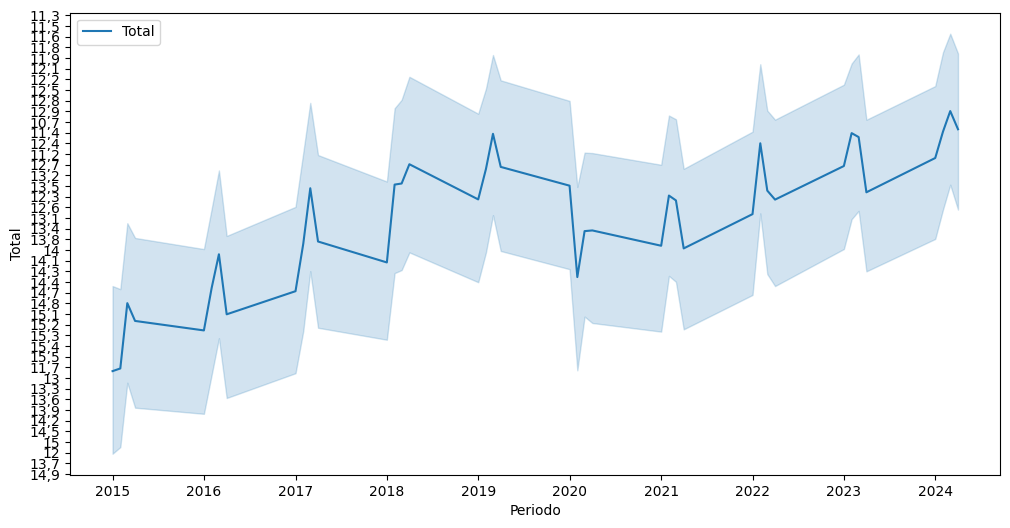

In [24]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado
sns.lineplot(x='Periodo', y='Sexo_Hombres', data=df, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Sexo_Mujeres', data=df, label='Mujeres', linestyle='--')

plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.legend(title='Sexo')
plt.show()


In [25]:
print(df[['Sexo_Hombres', 'Sexo_Mujeres']].head())


KeyError: "None of [Index(['Sexo_Hombres', 'Sexo_Mujeres'], dtype='object')] are in the [columns]"

ValueError: Could not interpret value `Sexo_Hombres` for `y`. An entry with this name does not appear in `data`.

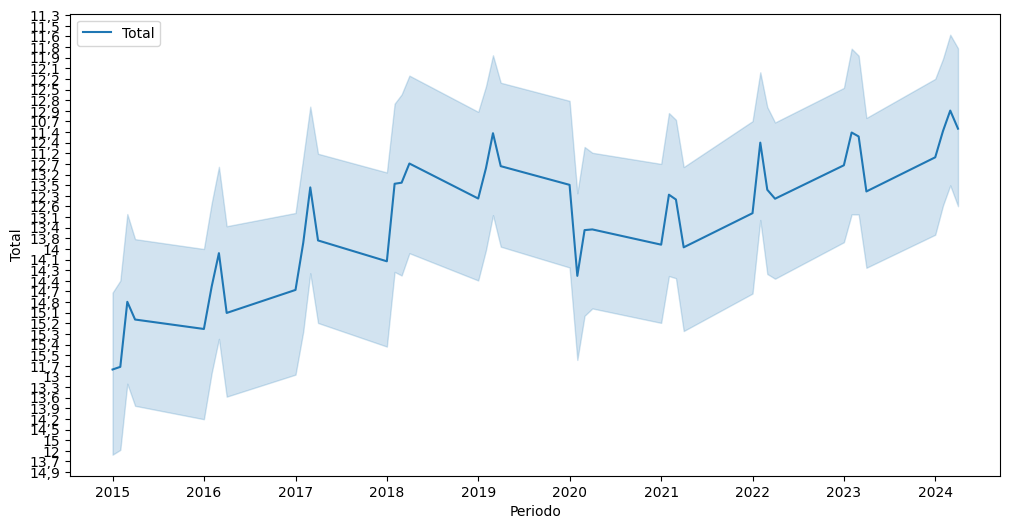

In [26]:
plt.figure(figsize=(12, 6))

# Graficar la serie de 'Total'
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar la serie de hombres (Sexo_Hombres = 1)
sns.lineplot(x='Periodo', y='Sexo_Hombres', data=df, label='Hombres', linestyle='--')

# Graficar la serie de mujeres (Sexo_Mujeres = 1)
sns.lineplot(x='Periodo', y='Sexo_Mujeres', data=df, label='Mujeres', linestyle='--')

plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.legend(title='Sexo')
plt.show()


In [27]:
print(df.head())


              Edad         Sexo      Unidad    Periodo Total  \
0  De 16 a 19 años  Ambos sexos  Porcentaje 2024-04-01   1,2   
1  De 16 a 19 años  Ambos sexos  Porcentaje 2024-03-01   1,6   
2  De 16 a 19 años  Ambos sexos  Porcentaje 2024-02-01   1,4   
3  De 16 a 19 años  Ambos sexos  Porcentaje 2024-01-01   1,2   
4  De 16 a 19 años  Ambos sexos  Porcentaje 2023-04-01   1,1   

                                         source_file  
0  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
1  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
2  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
3  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  
4  C:\Users\alber\OneDrive\Escritorio\data_set\Ac...  


In [28]:
print(df['Sexo'].unique())


['Ambos sexos' 'Hombres' 'Mujeres']


In [29]:
# Crear las columnas de sexo
df['Sexo_Hombres'] = df['Sexo'].apply(lambda x: 1 if x in ['Hombres', 'Ambos sexos'] else 0)
df['Sexo_Mujeres'] = df['Sexo'].apply(lambda x: 1 if x in ['Mujeres', 'Ambos sexos'] else 0)

# Verificar las nuevas columnas
print(df[['Sexo', 'Sexo_Hombres', 'Sexo_Mujeres']].head())


          Sexo  Sexo_Hombres  Sexo_Mujeres
0  Ambos sexos             1             1
1  Ambos sexos             1             1
2  Ambos sexos             1             1
3  Ambos sexos             1             1
4  Ambos sexos             1             1


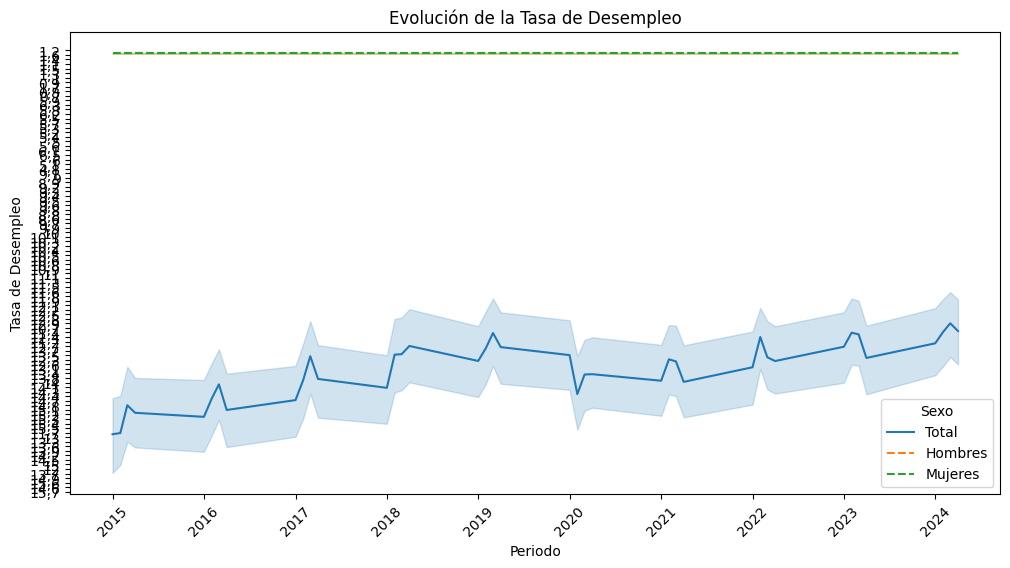

In [30]:
# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar el total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado
sns.lineplot(x='Periodo', y='Sexo_Hombres', data=df, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Sexo_Mujeres', data=df, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\1362008224.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


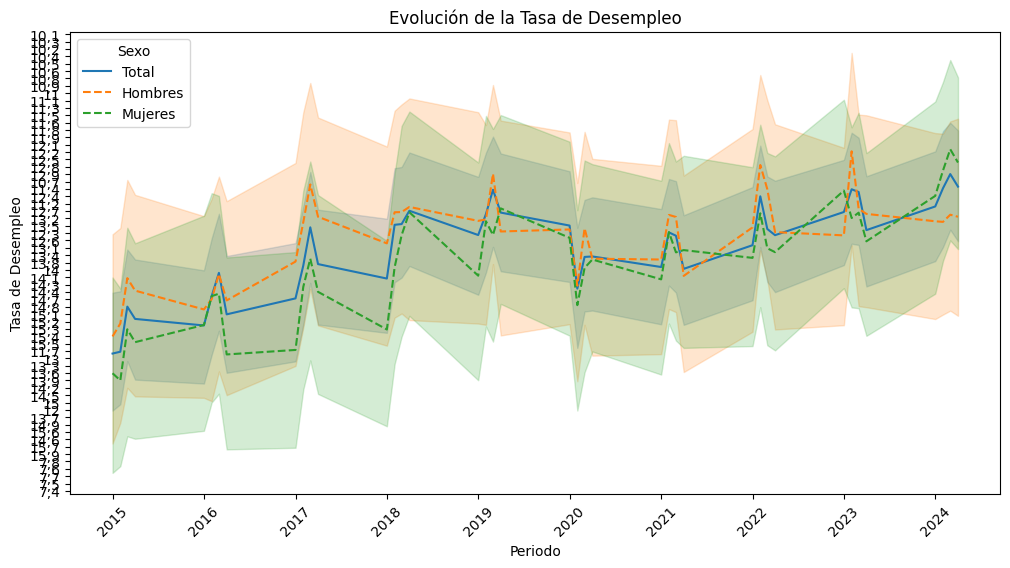

KeyError: "['Sexo'] not in index"

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar la serie de desempleo total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado, filtrando por 'Sexo'
df_hombres = df[df['Sexo'] == 'Hombres']
df_mujeres = df[df['Sexo'] == 'Mujeres']

sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Selección de características y target
if 'Sexo' in df.columns:  # Usamos la columna 'Sexo' en lugar de 'Sexo_Hombres' y 'Sexo_Mujeres'
    features = ['Edad', 'Sexo']  # Ajustar según los datos disponibles
    df = df.dropna()  # Eliminar filas con valores nulos

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        # Convertir la columna 'Sexo' en variables dummy (una para cada valor único de 'Sexo')
        df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Esto crea columnas para 'Hombres' y 'Mujeres'

        X = df[features]  # Las características a usar
        y = df['Total']  # La variable objetivo (Total)

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\1635846436.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


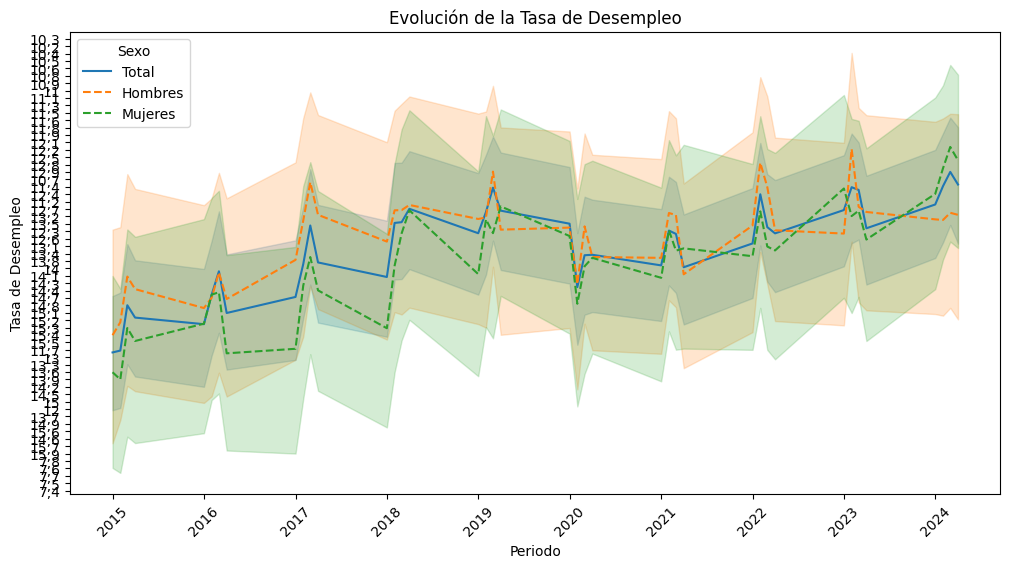

ValueError: could not convert string to float: 'De 55 a 59 años'

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar la serie de desempleo total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado, filtrando por 'Sexo'
df_hombres = df[df['Sexo'] == 'Hombres']
df_mujeres = df[df['Sexo'] == 'Mujeres']

sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Selección de características y target
if 'Sexo' in df.columns:  # Usamos la columna 'Sexo' en lugar de 'Sexo_Hombres' y 'Sexo_Mujeres'
    # Primero, eliminamos cualquier fila con valores nulos en las columnas relevantes
    df = df.dropna(subset=['Edad', 'Sexo', 'Total'])

    # Convertir la columna 'Sexo' en variables dummy (una para cada valor único de 'Sexo')
    df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Esto crea columnas para 'Hombres' y 'Mujeres'

    # Actualizar las características a utilizar (ahora 'Sexo_Hombres' y 'Sexo_Mujeres' estarán en el dataframe)
    features = ['Edad', 'Sexo_Hombres', 'Sexo_Mujeres']  # Asegurarse de que las columnas existan

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        X = df[features]  # Las características a usar
        y = df['Total']  # La variable objetivo (Total)

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\2409857376.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


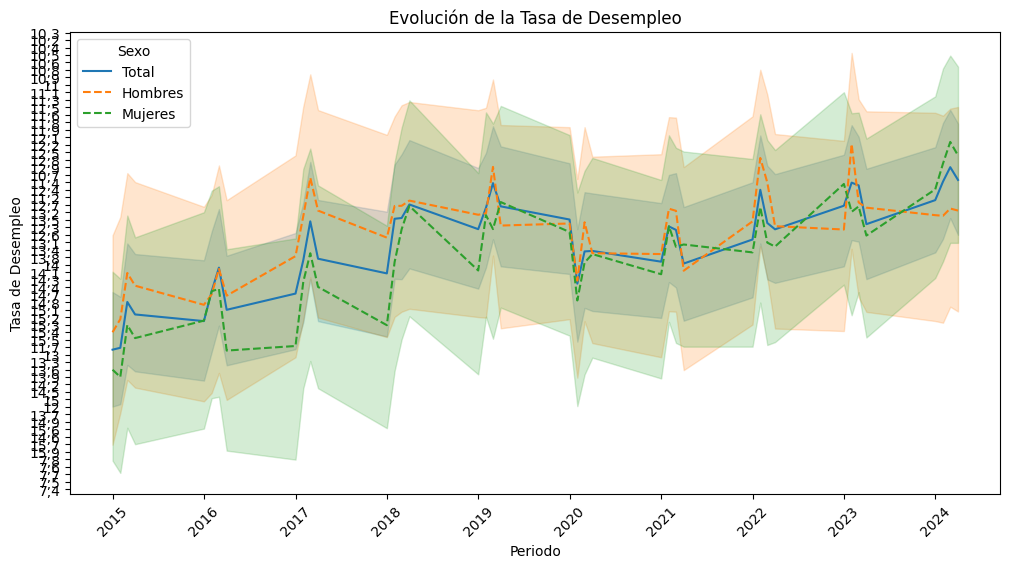

ValueError: could not convert string to float: '1,1'

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Limpiar la columna 'Edad' para convertir los rangos de edad a valores numéricos (promedio)
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            # Extraer los valores numéricos de los rangos de edad y calcular el promedio
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        else:
            return float(edad_str)  # Si es un número solo, lo dejamos como está
    except:
        return np.nan  # Si no se puede convertir, lo dejamos como NaN

df['Edad'] = df['Edad'].apply(convertir_edad)

# Verificar si se han convertido correctamente las edades
print(df['Edad'].head())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar la serie de desempleo total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado, filtrando por 'Sexo'
df_hombres = df[df['Sexo'] == 'Hombres']
df_mujeres = df[df['Sexo'] == 'Mujeres']

sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Selección de características y target
if 'Sexo' in df.columns:  # Usamos la columna 'Sexo' en lugar de 'Sexo_Hombres' y 'Sexo_Mujeres'
    # Primero, eliminamos cualquier fila con valores nulos en las columnas relevantes
    df = df.dropna(subset=['Edad', 'Sexo', 'Total'])

    # Convertir la columna 'Sexo' en variables dummy (una para cada valor único de 'Sexo')
    df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Esto crea columnas para 'Hombres' y 'Mujeres'

    # Actualizar las características a utilizar (ahora 'Sexo_Hombres' y 'Sexo_Mujeres' estarán en el dataframe)
    features = ['Edad', 'Sexo_Hombres', 'Sexo_Mujeres']  # Asegurarse de que las columnas existan

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        X = df[features]  # Las características a usar
        y = df['Total']  # La variable objetivo (Total)

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Limpiar la columna 'Edad' para convertir los rangos de edad a valores numéricos (promedio)
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            # Extraer los valores numéricos de los rangos de edad y calcular el promedio
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        else:
            return float(edad_str)  # Si es un número solo, lo dejamos como está
    except:
        return np.nan  # Si no se puede convertir, lo dejamos como NaN

df['Edad'] = df['Edad'].apply(convertir_edad)

# Verificar si se han convertido correctamente las edades
print(df['Edad'].head())

# Convertir la columna 'Total' a numérico, eliminando comas y convirtiendo a float
df['Total'] = df['Total'].replace({',': '.'}, regex=True).astype(float)

# Verificar si la columna 'Total' está correctamente convertida
print(df['Total'].head())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar la serie de desempleo total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado, filtrando por 'Sexo'
df_hombres = df[df['Sexo'] == 'Hombres']
df_mujeres = df[df['Sexo'] == 'Mujeres']

sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Selección de características y target
if 'Sexo' in df.columns:  # Usamos la columna 'Sexo' en lugar de 'Sexo_Hombres' y 'Sexo_Mujeres'
    # Primero, eliminamos cualquier fila con valores nulos en las columnas relevantes
    df = df.dropna(subset=['Edad', 'Sexo', 'Total'])

    # Convertir la columna 'Sexo' en variables dummy (una para cada valor único de 'Sexo')
    df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Esto crea columnas para 'Hombres' y 'Mujeres'

    # Actualizar las características a utilizar (ahora 'Sexo_Hombres' y 'Sexo_Mujeres' estarán en el dataframe)
    features = ['Edad', 'Sexo_Hombres', 'Sexo_Mujeres']  # Asegurarse de que las columnas existan

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        X = df[features]  # Las características a usar
        y = df['Total']  # La variable objetivo (Total)

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\3718831902.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


ValueError: could not convert string to float: '..'

In [35]:
import pandas as pd
import numpy as np

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")

# Convertir la columna 'Total' a numérico, eliminando comas y valores no numéricos
df['Total'] = df['Total'].replace({',': '.'}, regex=True)  # Reemplazar comas por puntos
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')  # Convertir a numérico, invalidos se convertirán en NaN

# Verificar si la columna 'Total' está correctamente convertida
print(df['Total'].head())

# Eliminar filas con valores nulos en 'Total' si es necesario
df = df.dropna(subset=['Total'])

# Continuar con el análisis


0    1.2
1    1.6
2    1.4
3    1.2
4    1.1
Name: Total, dtype: float64


In [37]:
# Reemplazar los valores ".." o similares por NaN
df['Total'] = df['Total'].replace(['..', '...'], np.nan)

# Eliminar filas donde 'Total' sea NaN para evitar errores en la conversión
df = df.dropna(subset=['Total'])

# Convertir la columna 'Total' a numérico después de limpiar los datos
df['Total'] = df['Total'].replace({',': '.'}, regex=True).astype(float)

# Verificar la conversión
print(df['Total'].head())


0    1.2
1    1.6
2    1.4
3    1.2
4    1.1
Name: Total, dtype: float64


C:\Users\alber\AppData\Local\Temp\ipykernel_20196\297964057.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total'] = df['Total'].replace({',': '.'}, regex=True).astype(float)


In [39]:
print(df['Total'].unique())  # Muestra los valores únicos de la columna


['1,2' '1,6' '1,4' '1,1' '1,5' '1,3' '1' '0,9' '1,7' '0,8' '0,7' '5,9'
 '6,3' '5,8' '6,2' '5,5' '5,7' '5,3' '5,2' '5,4' '5' '5,6' '6,1' '6,5' '6'
 '5,1' '4,8' '9,1' '9' '8,9' '9,2' '9,3' '9,4' '9,5' '9,6' '9,8' '8,8'
 '8,6' '9,7' '9,9' '10' '10,1' '10,3' '10,2' '10,4' '10,5' '10,6' '10,8'
 '10,9' '11' '11,1' '11,3' '11,5' '11,6' '11,8' '11,9' '12,1' '12,2'
 '12,5' '12,8' '12,9' '10,7' '11,4' '12,4' '11,2' '12,7' '13,2' '13,5'
 '12,3' '12,6' '13,1' '13,4' '13,8' '14' '14,1' '14,3' '14,4' '14,7'
 '14,8' '15,1' '15,2' '15,3' '15,4' '15,5' '11,7' '13' '13,3' '13,6'
 '13,9' '14,2' '14,5' '15' '12' '13,7' '14,9' '15,6' '14,6' '15,7' '15,9'
 '7,8' '7,6' '7,7' '7,5' '7,4' '7,3' '7,2' '7,1' '7' '6,9' '6,7' '6,4'
 '4,9' '4,7' '4,6' '4,5' '8' '6,8' '6,6' '4,4' '4,3' '4,1' '0,6' '0,5'
 '0,2' '0,3' '0,1' '0,4' '4,2' '3,9' '4' '3,7' '3,8' '3,6' '8,7' '8,5'
 '8,4' '8,2' '8,1' '8,3' '7,9' '15,8' '16' '16,1' '16,2' '16,3' '16,4'
 '3,1' '3,5' '3,2' '3,4' '3' '3,3' '2,9' '2,6' '2,7' '2,4' '2,8' '0' '..']

In [40]:
import numpy as np

df['Total'] = df['Total'].replace({',': '.'}, regex=True)  # Reemplazar comas por puntos
df['Total'] = df['Total'].replace({'..': np.nan})  # Reemplazar '..' por NaN
df['Total'] = df['Total'].astype(float)  # Convertir a float


In [41]:
df = df[df['Total'] != '..']
df['Total'] = df['Total'].astype(float)


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Elegir el dataframe adecuado para el análisis (en este caso df_laboral como ejemplo)
df = df_laboral

# Imprimir las columnas para ver si 'Sexo_Hombres' y 'Sexo_Mujeres' están presentes
print(df.columns)

# Inspeccionar los datos
print(df.info())  # Información general del dataset
print(df.describe())  # Estadísticas descriptivas

# Convertir la columna 'Periodo' en formato de fecha si es necesario
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Verificar si hay algún valor nulo después de la conversión
print(df['Periodo'].isnull().sum())

# Limpiar la columna 'Edad' para convertir los rangos de edad a valores numéricos (promedio)
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            # Extraer los valores numéricos de los rangos de edad y calcular el promedio
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        else:
            return float(edad_str)  # Si es un número solo, lo dejamos como está
    except:
        return np.nan  # Si no se puede convertir, lo dejamos como NaN

df['Edad'] = df['Edad'].apply(convertir_edad)

# Verificar si se han convertido correctamente las edades
print(df['Edad'].head())

# Convertir la columna 'Total' a numérico, eliminando comas y convirtiendo a float
df['Total'] = df['Total'].replace({',': '.'}, regex=True).astype(float)

# Verificar si la columna 'Total' está correctamente convertida
print(df['Total'].head())

# Visualizar la tendencia del desempleo en el tiempo
plt.figure(figsize=(12, 6))

# Graficar la serie de desempleo total
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Graficar las series de hombres y mujeres por separado, filtrando por 'Sexo'
df_hombres = df[df['Sexo'] == 'Hombres']
df_mujeres = df[df['Sexo'] == 'Mujeres']

sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

# Título y ajuste de etiquetas
plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Selección de características y target
if 'Sexo' in df.columns:  # Usamos la columna 'Sexo' en lugar de 'Sexo_Hombres' y 'Sexo_Mujeres'
    # Primero, eliminamos cualquier fila con valores nulos en las columnas relevantes
    df = df.dropna(subset=['Edad', 'Sexo', 'Total'])

    # Convertir la columna 'Sexo' en variables dummy (una para cada valor único de 'Sexo')
    df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Esto crea columnas para 'Hombres' y 'Mujeres'

    # Actualizar las características a utilizar (ahora 'Sexo_Hombres' estará en el dataframe)
    features = ['Edad', 'Sexo_Hombres']  # Sólo 'Sexo_Hombres' se usará para evitar multicolinealidad

    # Verificar si la columna 'Total' está presente
    if 'Total' not in df.columns:
        print("La columna 'Total' no está presente en el dataset.")
    else:
        X = df[features]  # Las características a usar
        y = df['Total']  # La variable objetivo (Total)

        # Dividir en conjunto de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Escalar las características
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Entrenar modelos
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
        model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

        model_rf.fit(X_train, y_train)
        model_xgb.fit(X_train, y_train)

        # Evaluación de modelos
        def evaluar_modelo(modelo, X_test, y_test):
            y_pred = modelo.predict(X_test)
            print(f"Modelo: {modelo.__class__.__name__}")
            print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
            print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
            print(f"R2 Score: {r2_score(y_test, y_pred)}\n")

        evaluar_modelo(model_rf, X_test, y_test)
        evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


Index(['Edad', 'Sexo', 'Unidad', 'Periodo', 'Total', 'source_file'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                      

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\3146387109.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


ValueError: could not convert string to float: '..'

In [43]:
print(df['Total'].unique())  # Muestra los valores únicos de la columna


['1,2' '1,6' '1,4' '1,1' '1,5' '1,3' '1' '0,9' '1,7' '0,8' '0,7' '5,9'
 '6,3' '5,8' '6,2' '5,5' '5,7' '5,3' '5,2' '5,4' '5' '5,6' '6,1' '6,5' '6'
 '5,1' '4,8' '9,1' '9' '8,9' '9,2' '9,3' '9,4' '9,5' '9,6' '9,8' '8,8'
 '8,6' '9,7' '9,9' '10' '10,1' '10,3' '10,2' '10,4' '10,5' '10,6' '10,8'
 '10,9' '11' '11,1' '11,3' '11,5' '11,6' '11,8' '11,9' '12,1' '12,2'
 '12,5' '12,8' '12,9' '10,7' '11,4' '12,4' '11,2' '12,7' '13,2' '13,5'
 '12,3' '12,6' '13,1' '13,4' '13,8' '14' '14,1' '14,3' '14,4' '14,7'
 '14,8' '15,1' '15,2' '15,3' '15,4' '15,5' '11,7' '13' '13,3' '13,6'
 '13,9' '14,2' '14,5' '15' '12' '13,7' '14,9' '15,6' '14,6' '15,7' '15,9'
 '7,8' '7,6' '7,7' '7,5' '7,4' '7,3' '7,2' '7,1' '7' '6,9' '6,7' '6,4'
 '4,9' '4,7' '4,6' '4,5' '8' '6,8' '6,6' '4,4' '4,3' '4,1' '0,6' '0,5'
 '0,2' '0,3' '0,1' '0,4' '4,2' '3,9' '4' '3,7' '3,8' '3,6' '8,7' '8,5'
 '8,4' '8,2' '8,1' '8,3' '7,9' '15,8' '16' '16,1' '16,2' '16,3' '16,4'
 '3,1' '3,5' '3,2' '3,4' '3' '3,3' '2,9' '2,6' '2,7' '2,4' '2,8' '0' '..']

In [44]:
import numpy as np

# Reemplazar ".." con NaN
df['Total'] = df['Total'].replace("..", np.nan)

# Reemplazar comas por puntos y convertir a float
df['Total'] = df['Total'].str.replace(",", ".").astype(float)

# Verificar los primeros valores después de la conversión
print(df['Total'].head())
print(df['Total'].dtype)


0    1.2
1    1.6
2    1.4
3    1.2
4    1.1
Name: Total, dtype: float64
float64


In [45]:
print(df['Total'].unique())  # Muestra los valores únicos de la columna


[ 1.2  1.6  1.4  1.1  1.5  1.3  1.   0.9  1.7  0.8  0.7  5.9  6.3  5.8
  6.2  5.5  5.7  5.3  5.2  5.4  5.   5.6  6.1  6.5  6.   5.1  4.8  9.1
  9.   8.9  9.2  9.3  9.4  9.5  9.6  9.8  8.8  8.6  9.7  9.9 10.  10.1
 10.3 10.2 10.4 10.5 10.6 10.8 10.9 11.  11.1 11.3 11.5 11.6 11.8 11.9
 12.1 12.2 12.5 12.8 12.9 10.7 11.4 12.4 11.2 12.7 13.2 13.5 12.3 12.6
 13.1 13.4 13.8 14.  14.1 14.3 14.4 14.7 14.8 15.1 15.2 15.3 15.4 15.5
 11.7 13.  13.3 13.6 13.9 14.2 14.5 15.  12.  13.7 14.9 15.6 14.6 15.7
 15.9  7.8  7.6  7.7  7.5  7.4  7.3  7.2  7.1  7.   6.9  6.7  6.4  4.9
  4.7  4.6  4.5  8.   6.8  6.6  4.4  4.3  4.1  0.6  0.5  0.2  0.3  0.1
  0.4  4.2  3.9  4.   3.7  3.8  3.6  8.7  8.5  8.4  8.2  8.1  8.3  7.9
 15.8 16.  16.1 16.2 16.3 16.4  3.1  3.5  3.2  3.4  3.   3.3  2.9  2.6
  2.7  2.4  2.8  0.   nan]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None
                   Edad         Sexo      Unidad Periodo Total  \
count              4320         4320        4320    4320  4320   
unique               12            3           1      40   159   
top     De 16 a 19 años  Ambos sexos  Porcentaje  2024T4   0,2   
freq                360         1440        4320     108   148   

                                              source_file  
count                                                4320  
unique                                                  3  
top     

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\2846981819.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')


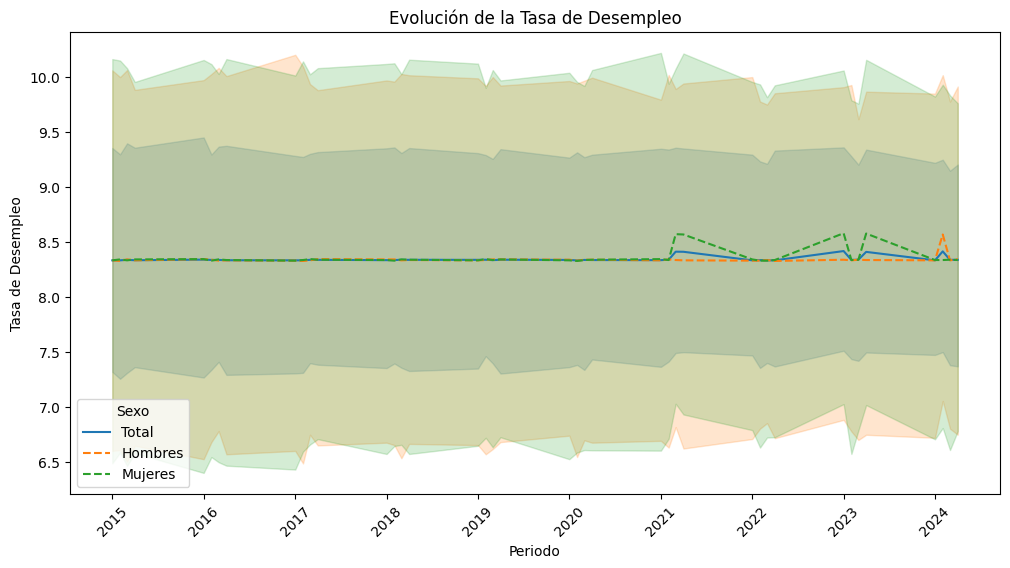

Modelo: RandomForestRegressor
MAE: 1.2720
RMSE: 1.6199
R2 Score: 0.8766

Modelo: XGBRegressor
MAE: 1.2713
RMSE: 1.6188
R2 Score: 0.8768



In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset (ajusta según lo que corresponda)
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")
df_tasas = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_tasas.csv")
df_sectores = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_sectores.csv")
df_formacion = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_formacion.csv")
df_productividad = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_productividad.csv")

# Seleccionar el dataset principal para el análisis
df = df_laboral

# Inspeccionar datos
print(df.info())  # Información general
print(df.describe())  # Estadísticas descriptivas

# Convertir 'Periodo' a tipo fecha
df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce')

# Limpiar la columna 'Edad'
def convertir_edad(edad_str):
    try:
        if isinstance(edad_str, str) and 'a' in edad_str:
            partes = edad_str.split(' a ')
            return (int(partes[0].split(' ')[-1]) + int(partes[1].split(' ')[0])) / 2
        return float(edad_str)
    except:
        return np.nan  # Si no se puede convertir, lo dejamos como NaN

df['Edad'] = df['Edad'].apply(convertir_edad)

# Convertir la columna 'Total' a numérico
df['Total'] = df['Total'].replace("..", np.nan)  # Reemplazar valores ".." por NaN
df['Total'] = df['Total'].str.replace(",", ".").astype(float)  # Convertir a float

# Verificar la conversión
print(df[['Edad', 'Total']].head())

# Visualización de la evolución del desempleo
plt.figure(figsize=(12, 6))
sns.lineplot(x='Periodo', y='Total', data=df, label='Total')

# Si 'Sexo' está presente, graficamos por género
if 'Sexo' in df.columns:
    df_hombres = df[df['Sexo'] == 'Hombres']
    df_mujeres = df[df['Sexo'] == 'Mujeres']

    sns.lineplot(x='Periodo', y='Total', data=df_hombres, label='Hombres', linestyle='--')
    sns.lineplot(x='Periodo', y='Total', data=df_mujeres, label='Mujeres', linestyle='--')

plt.title('Evolución de la Tasa de Desempleo')
plt.xticks(rotation=45)
plt.xlabel('Periodo')
plt.ylabel('Tasa de Desempleo')
plt.legend(title='Sexo')
plt.show()

# Preprocesamiento para modelos de Machine Learning
if 'Sexo' in df.columns:
    df = df.dropna(subset=['Edad', 'Sexo', 'Total'])

    # Convertir 'Sexo' en variables dummy
    df = pd.get_dummies(df, columns=['Sexo'], drop_first=True)  # Crea 'Sexo_Mujeres' (1 si es mujer, 0 si es hombre)

    # Definir características y variable objetivo
    features = ['Edad', 'Sexo_Mujeres']
    X = df[features]
    y = df['Total']

    # Dividir en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalar características
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Modelos de regresión
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

    model_rf.fit(X_train, y_train)
    model_xgb.fit(X_train, y_train)

    # Función de evaluación
    def evaluar_modelo(modelo, X_test, y_test):
        y_pred = modelo.predict(X_test)
        print(f"Modelo: {modelo.__class__.__name__}")
        print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
        print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
        print(f"R2 Score: {r2_score(y_test, y_pred):.4f}\n")

    # Evaluación de modelos
    evaluar_modelo(model_rf, X_test, y_test)
    evaluar_modelo(model_xgb, X_test, y_test)
else:
    print("La columna 'Sexo' no está presente en el dataset.")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === 1. Cargar los datos ===
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")

# === 2. Inspeccionar y limpiar los datos ===
print("Información del dataset antes de la limpieza:")
print(df_laboral.info())

dad'] = df_laboral['Edad'].astype(str).apply(convertir_edad)

# ---- Limpiar la columna 'Total' ----
df_laboral['Total'] = (
    df_laboral['Total']
    .astype(str)  
    .str.replace(',', '.', regex=True)  # Reemplazar comas por puntos
    .replace(['..', ''], np.nan)  # Reemplazar valores no numéricos por NaN
    .astype(float)  # Convertir a float
)

# ---- Convertir 'Sexo' en variables numéricas ----
if 'Sexo' in df_laboral.columns:
    df_laboral = pd.get_dummies(df_laboral, columns=['Sexo'], drop_first=True)

# ---- Eliminar valores nulos tras la limpieza ----
df_laboral.dropna(subset=['Edad', 'Total'], inplace=True)# ---- Convertir 'Periodo' a datetime ----
df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')

# ---- Limpiar la columna 'Edad' ----
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        return float(edad_str)
    except:
        return np.nan  # Si hay error, asignamos NaN

df_laboral['E

# === 3. Explorar los datos tras la limpieza ===
print("\nInformación después de la limpieza:")
print(df_laboral.info())

# === 4. Modelado ===
# Selección de características y target
features = ['Edad']
if 'Sexo_Hombres' in df_laboral.columns:
    features.append('Sexo_Hombres')

X = df_laboral[features]
y = df_laboral['Total']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Entrenar modelos
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# Evaluación de modelos
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    print(f"\nModelo: {modelo.__class__.__name__}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

evaluar_modelo(model_rf, X_test, y_test)
evaluar_modelo(model_xgb, X_test, y_test)


Información del dataset antes de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None

Información después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 0 to 4199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Edad          3960 non-null   float64       
 1   Unidad        3960 non-null   object        
 2   Periodo       3960 non-null   datetime64[ns]
 3   Total         3960 non-null   float64       
 4   source_file   3960 non-null   

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\1016658091.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')



Modelo: RandomForestRegressor
MAE: 1.2821
RMSE: 1.6446
R2 Score: 0.8729

Modelo: XGBRegressor
MAE: 1.2819
RMSE: 1.6441
R2 Score: 0.8729


Información del dataset antes de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None

Información después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 0 to 4199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Edad          3960 non-null   float64       
 1   Unidad        3960 non-null   object        
 2   Periodo       3960 non-null   datetime64[ns]
 3   Total         3960 non-null   float64       
 4   source_file   3960 non-null   

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\4285987796.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')


Modelo: XGBRegressor
MAE: 1.2818767101475688
RMSE: 1.644147231175208
R2 Score: 0.8729217626088706



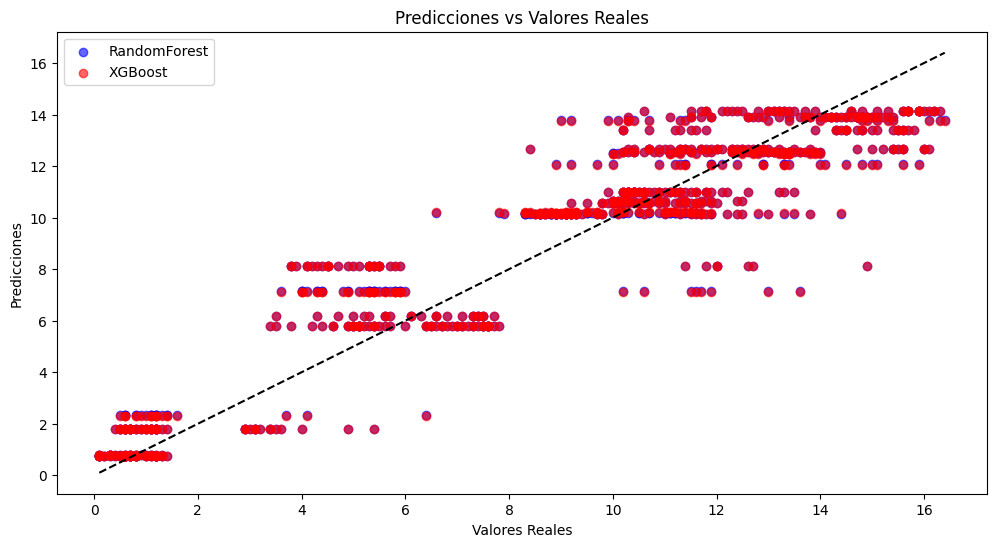

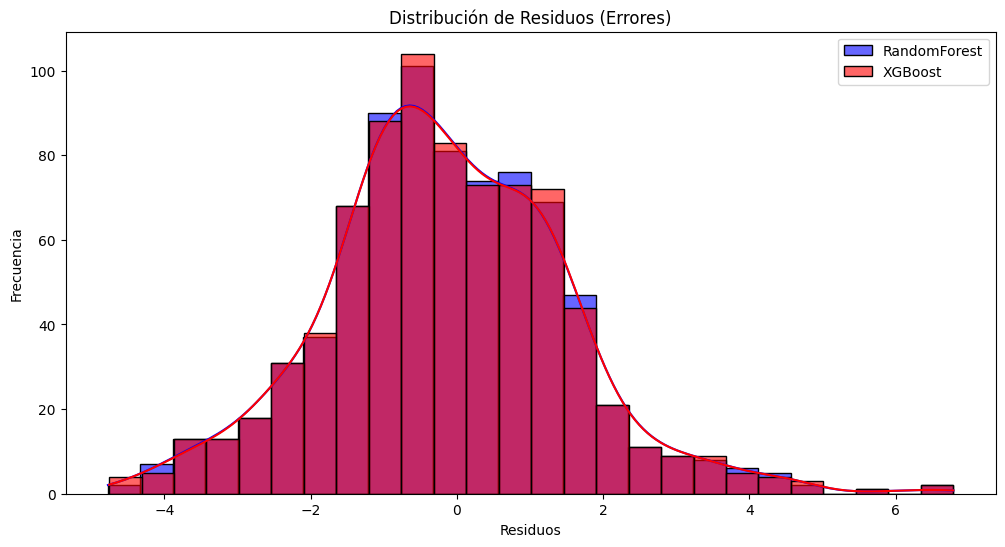

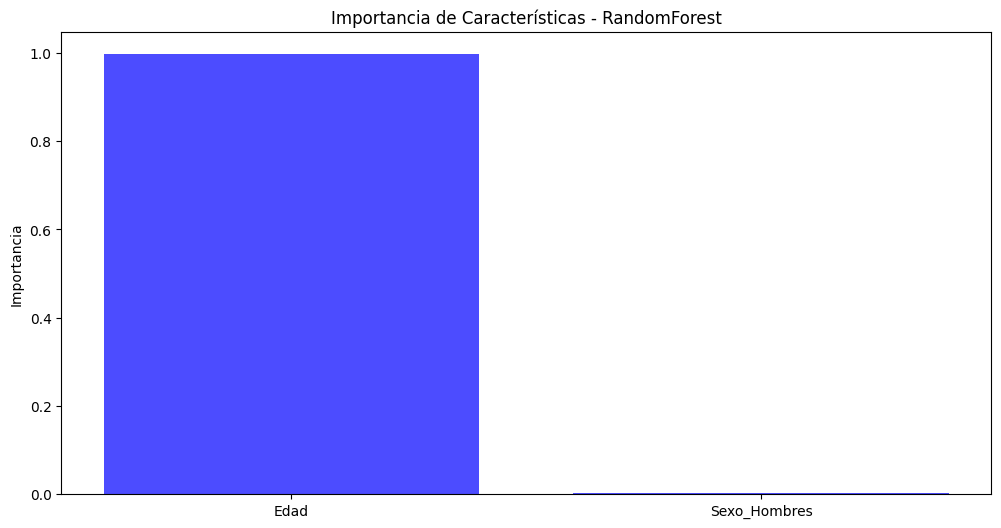

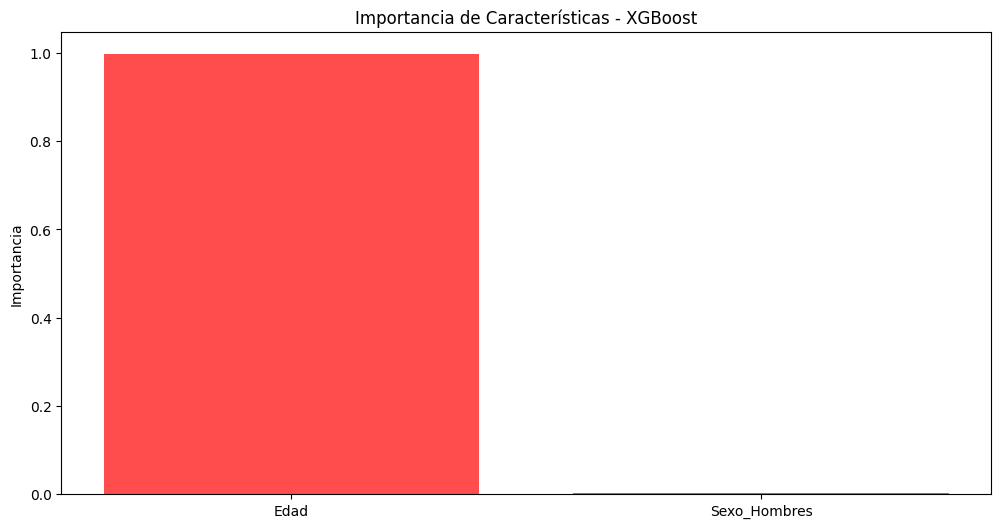

In [53]:
# === 1. Cargar los datos ===
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")

# === 2. Inspeccionar y limpiar los datos ===
print("Información del dataset antes de la limpieza:")
print(df_laboral.info())

# ---- Convertir 'Periodo' a datetime ----
df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')

# ---- Limpiar la columna 'Edad' ----
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        return float(edad_str)
    except:
        return np.nan  # Si hay error, asignamos NaN

df_laboral['Edad'] = df_laboral['Edad'].astype(str).apply(convertir_edad)

# ---- Limpiar la columna 'Total' ----
df_laboral['Total'] = (
    df_laboral['Total']
    .astype(str)  
    .str.replace(',', '.', regex=True)  # Reemplazar comas por puntos
    .replace(['..', ''], np.nan)  # Reemplazar valores no numéricos por NaN
    .astype(float)  # Convertir a float
)

# ---- Convertir 'Sexo' en variables numéricas ----
if 'Sexo' in df_laboral.columns:
    df_laboral = pd.get_dummies(df_laboral, columns=['Sexo'], drop_first=True)

# ---- Eliminar valores nulos tras la limpieza ----
df_laboral.dropna(subset=['Edad', 'Total'], inplace=True)

# === 3. Explorar los datos tras la limpieza ===
print("\nInformación después de la limpieza:")
print(df_laboral.info())



# Selección de características y target
X = df_laboral[['Edad', 'Sexo_Hombres']]
y = df_laboral['Total']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inicializar los modelos
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Entrenar los modelos
model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# Evaluación de los modelos
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}\n")
    
    return y_pred, y_test

# Evaluar ambos modelos
y_pred_rf, y_test_rf = evaluar_modelo(model_rf, X_test, y_test)
y_pred_xgb, y_test_xgb = evaluar_modelo(model_xgb, X_test, y_test)

# Gráficos

# 1. Gráfico de dispersión entre los valores reales y las predicciones
plt.figure(figsize=(12, 6))
plt.scatter(y_test_rf, y_pred_rf, color='blue', label='RandomForest', alpha=0.6)
plt.scatter(y_test_xgb, y_pred_xgb, color='red', label='XGBoost', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()

# 2. Gráfico de residuos (Errores) para ver si hay patrones
residuals_rf = y_test_rf - y_pred_rf
residuals_xgb = y_test_xgb - y_pred_xgb

plt.figure(figsize=(12, 6))
sns.histplot(residuals_rf, color='blue', kde=True, label='RandomForest', alpha=0.6)
sns.histplot(residuals_xgb, color='red', kde=True, label='XGBoost', alpha=0.6)
plt.title('Distribución de Residuos (Errores)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# 3. Gráfico de importancia de características
plt.figure(figsize=(12, 6))
feat_importances_rf = model_rf.feature_importances_
plt.bar(X.columns, feat_importances_rf, color='blue', alpha=0.7)
plt.title('Importancia de Características - RandomForest')
plt.ylabel('Importancia')
plt.show()

plt.figure(figsize=(12, 6))
feat_importances_xgb = model_xgb.feature_importances_
plt.bar(X.columns, feat_importances_xgb, color='red', alpha=0.7)
plt.title('Importancia de Características - XGBoost')
plt.ylabel('Importancia')
plt.show()


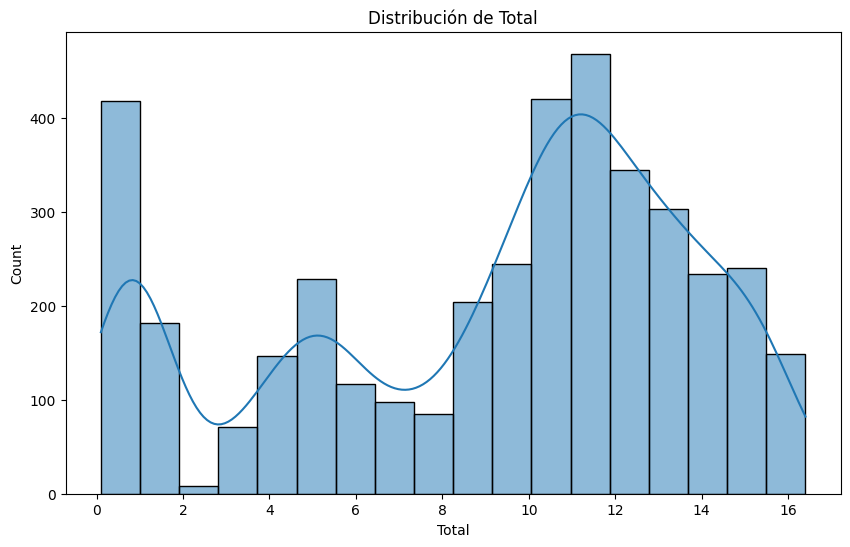

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(df_laboral['Total'], kde=True)
plt.title('Distribución de Total')
plt.show()


In [55]:
print(df_laboral['Sexo_Hombres'].value_counts())
print(df_laboral['Sexo_Mujeres'].value_counts())


Sexo_Hombres
False    2640
True     1320
Name: count, dtype: int64
Sexo_Mujeres
False    2640
True     1320
Name: count, dtype: int64


In [56]:
model_xgb = XGBRegressor(objective='reg:squarederror', scale_pos_weight=1, random_state=42)


In [60]:
pip install --upgrade scikit-learn xgboost



   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 1.2 MB/s eta 0:02:05
   ---------------------------------------- 1.0/150.0 MB 1.4 MB/s eta 0:01:47
   ---------------------------------------- 1.3/150.0 MB 1.5 MB/s eta 0:01:40
   ---------------------------------------- 1.8/150.0 MB 1.7 MB/s eta 0:01:29
    --------------------------------------- 2.1/150.0 MB 1.7 MB/s eta 0:01:26
    --------------------------------------- 2.6/150.0 MB 1.7 MB/s eta 0:01:27
    --------------------------------------- 2.6/150.0 MB 1.7 MB/s eta 0:01:27
    --------------------------------------- 2.6/150.0 MB 1.7 MB/s eta 0:01:27
    --------------------------------------- 2.9/150.0 MB 1.3 MB/s eta 0:01:50
    --------------------------------------- 2.9/150.0 MB 1.3 MB/s eta 0:01:50
    --

  You can safely remove it manually.


Información del dataset antes de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Edad         4320 non-null   object
 1   Sexo         4320 non-null   object
 2   Unidad       4320 non-null   object
 3   Periodo      4320 non-null   object
 4   Total        4320 non-null   object
 5   source_file  4320 non-null   object
dtypes: object(6)
memory usage: 202.6+ KB
None

Información después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
Index: 3960 entries, 0 to 4199
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Edad          3960 non-null   float64       
 1   Unidad        3960 non-null   object        
 2   Periodo       3960 non-null   datetime64[ns]
 3   Total         3960 non-null   float64       
 4   source_file   3960 non-null   

C:\Users\alber\AppData\Local\Temp\ipykernel_20196\1970941332.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')


Modelo: RandomForestRegressor
MAE: 1.2821291518660127
RMSE: 1.644605291819865
R2 Score: 0.8728509445618636

Modelo: XGBRegressor
MAE: 1.2818767101475688
RMSE: 1.644147231175208
R2 Score: 0.8729217626088706



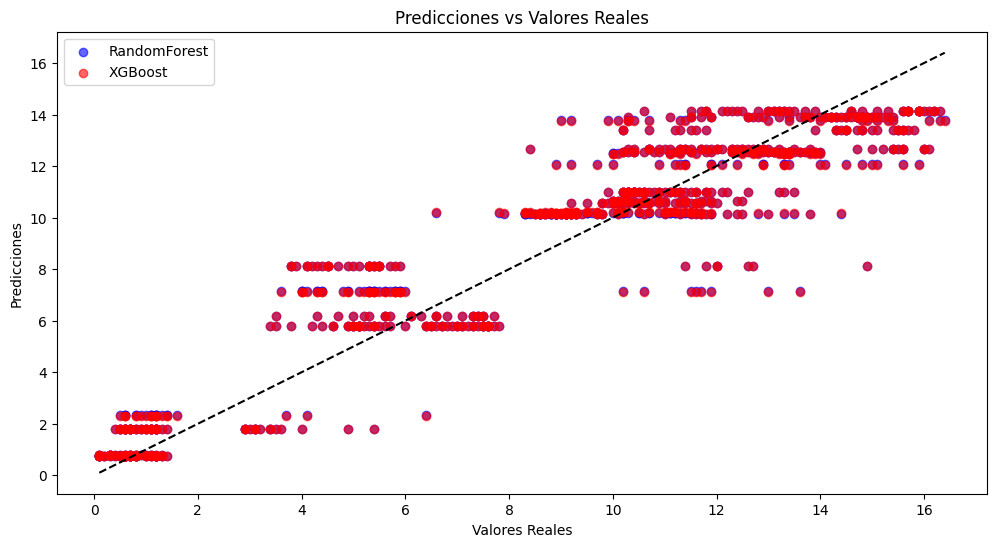

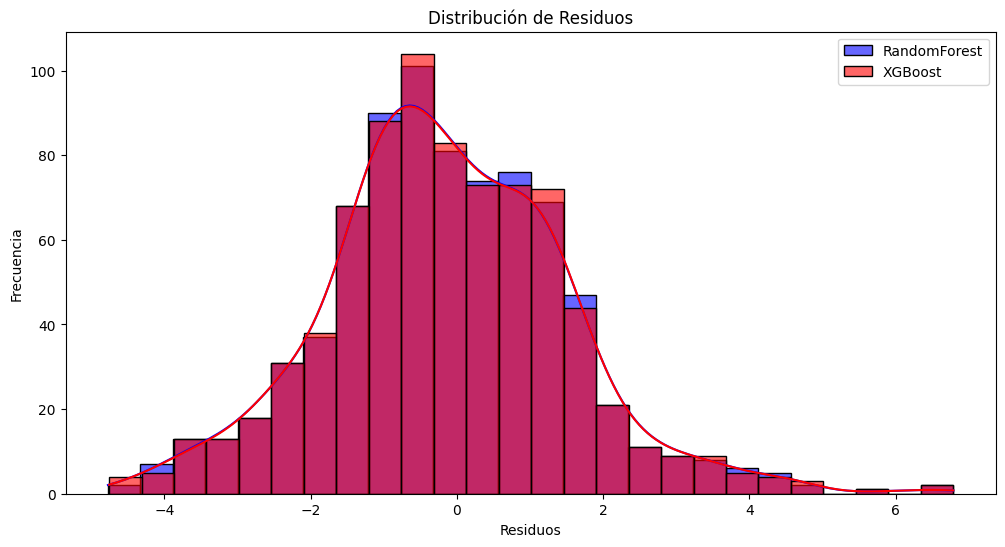

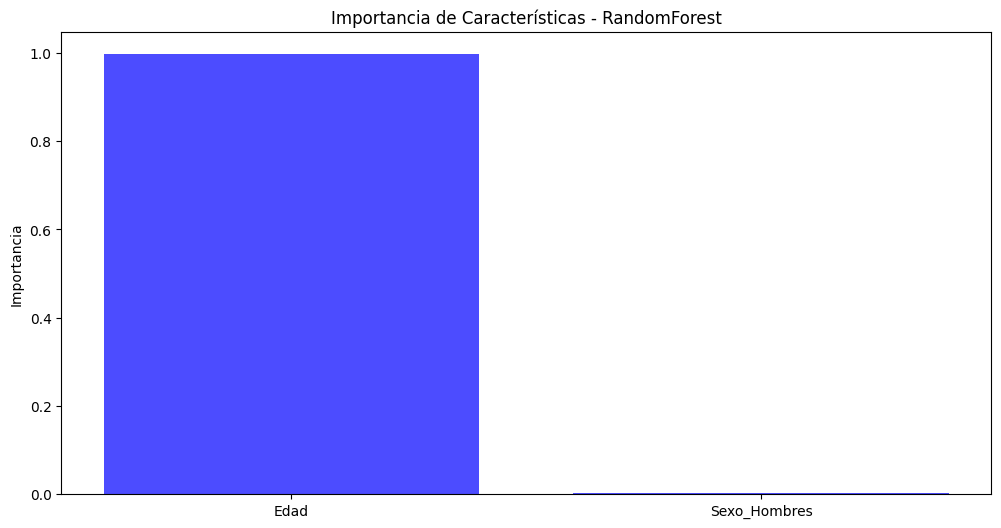

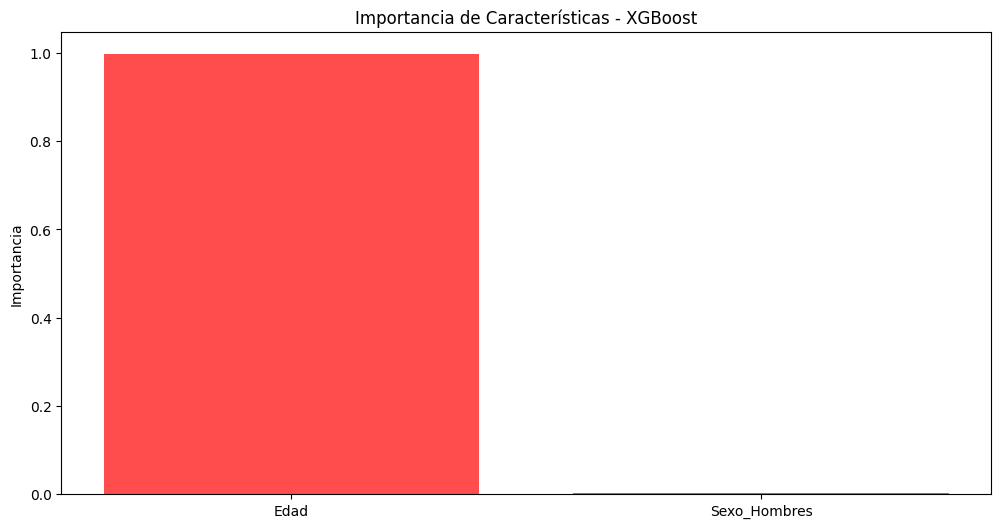

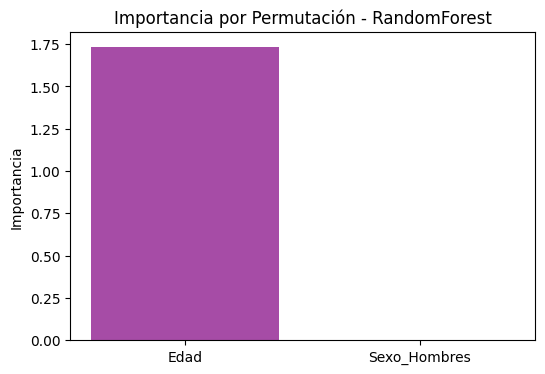

AttributeError: 'super' object has no attribute '__sklearn_tags__'

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# === 1. Cargar los datos ===
df_laboral = pd.read_csv(r"C:\Users\alber\OneDrive\Escritorio\data_set_consolidado\df_laboral.csv")

# === 2. Inspeccionar y limpiar los datos ===
print("Información del dataset antes de la limpieza:")
print(df_laboral.info())

# Convertir 'Periodo' a datetime
df_laboral['Periodo'] = pd.to_datetime(df_laboral['Periodo'], errors='coerce')

# Función para limpiar la columna 'Edad'
def convertir_edad(edad_str):
    try:
        if 'a' in edad_str:
            rangos = edad_str.split(' a ')
            return (int(rangos[0].split(' ')[-1]) + int(rangos[1].split(' ')[0])) / 2
        return float(edad_str)
    except:
        return np.nan

df_laboral['Edad'] = df_laboral['Edad'].astype(str).apply(convertir_edad)

# Limpiar la columna 'Total'
df_laboral['Total'] = (
    df_laboral['Total']
    .astype(str)  
    .str.replace(',', '.', regex=True)
    .replace(['..', ''], np.nan)
    .astype(float)
)

# Convertir 'Sexo' en variables numéricas
df_laboral = pd.get_dummies(df_laboral, columns=['Sexo'], drop_first=True)

# Eliminar valores nulos tras la limpieza
df_laboral.dropna(subset=['Edad', 'Total'], inplace=True)

print("\nInformación después de la limpieza:")
print(df_laboral.info())

# === 3. Selección de características ===
X = df_laboral[['Edad', 'Sexo_Hombres']]
y = df_laboral['Total']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 4. Entrenar modelos ===
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

model_rf.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# === 5. Evaluación de modelos ===
def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2}\n")
    return y_pred

y_pred_rf = evaluar_modelo(model_rf, X_test, y_test)
y_pred_xgb = evaluar_modelo(model_xgb, X_test, y_test)

# === 6. Gráficos ===
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_rf, color='blue', label='RandomForest', alpha=0.6)
plt.scatter(y_test, y_pred_xgb, color='red', label='XGBoost', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()

# Distribución de residuos
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(12, 6))
sns.histplot(residuals_rf, color='blue', kde=True, label='RandomForest', alpha=0.6)
sns.histplot(residuals_xgb, color='red', kde=True, label='XGBoost', alpha=0.6)
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Importancia de características
plt.figure(figsize=(12, 6))
plt.bar(X.columns, model_rf.feature_importances_, color='blue', alpha=0.7)
plt.title('Importancia de Características - RandomForest')
plt.ylabel('Importancia')
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(X.columns, model_xgb.feature_importances_, color='red', alpha=0.7)
plt.title('Importancia de Características - XGBoost')
plt.ylabel('Importancia')
plt.show()

# === 7. Importancia de características con permutación ===
def importancia_permutacion(modelo, X_test, y_test, modelo_nombre):
    resultado = permutation_importance(modelo, X_test, y_test, scoring='r2', n_repeats=10, random_state=42)
    importancia = resultado.importances_mean
    plt.figure(figsize=(6, 4))
    plt.bar(X.columns, importancia, color='purple', alpha=0.7)
    plt.title(f'Importancia por Permutación - {modelo_nombre}')
    plt.ylabel('Importancia')
    plt.show()

importancia_permutacion(model_rf, X_test, y_test, "RandomForest")
importancia_permutacion(model_xgb, X_test, y_test, "XGBoost")